In [ ]:
import numpy as np
import pandas as pd
from ins_pricing import bayesopt as ropt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.multiprocessing as mp
from pathlib import Path
import os

# Work in current directory - compatible with pip-installed package
work_dir = Path.cwd()

os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [ ]:
# Parameter definitions - use relative paths from current working directory
# Data should be in a 'Data' subdirectory of where you run this notebook
data_dir = work_dir / 'Data'
if not data_dir.exists():
    raise FileNotFoundError(f'Data directory not found at {data_dir}. Please create it and add your data files.')

# Output directory for models and plots
output_dir = work_dir / 'Results'

prop_test = 0.25
rand_seed = 13
percentile_tgt = 0.95
tgt = 'response'
wght = 'weights'
# ['od', 'ctp', 'tp', 'ctp_bi', 'ctp_pd', 'tp_bi', 'tp_pd']
model_list = ['od']
model_cate = ['bc']  # ['f', 's', 'bc']
model_names = []
for chr in model_cate:
    model_names += list(map(lambda x: x + '_' + chr, model_list))
# Define modeling feature list
feature_list = [
    'age_owner', 'gender_owner',
    'plt_zone', 'cheling_year', 'carbrand', 'carkind',
    'cartype', 'grpcode', 'pl', 'power_type',
    'price', 'qualitymax', 'seat_num', 'trans_type',
    'absflag', 'airbagcount',
    'btype', 'lastnum_2y_bi', 'lastnum_2y_ctp', 'cover',
    'L', 'N', 'cover_chg', 'delay_ins',
    'medication_mrk', 'owner_insured', 'tplimit',
    'channel', 'dpt',
    'chd_mileage_day', 'chd_mileage_total', 'chd_num_atten', 'chd_num_prov',
    'chd_r_unfam_road', 'chd_speed_total', 'chd_time_total', 'chd_triprate_prov'
]
# Define categorical features
categorical_features = [
    'gender_owner',
    'plt_zone', 'cheling_year', 'carbrand', 'carkind',
    'cartype', 'grpcode', 'pl', 'power_type',
    'price', 'seat_num', 'trans_type',
    'absflag', 'airbagcount',
    'btype', 'lastnum_2y_bi', 'lastnum_2y_ctp', 'cover',
    'cover_chg', 'delay_ins',
    'medication_mrk', 'owner_insured',
    'channel', 'dpt'
]

print(f"Working directory: {work_dir}")
print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")

model_dict = {}
for model in model_names:
    print('Model of %s is processing' % model)
    raw = pd.read_csv(data_dir / f'{model}.csv', low_memory=False)
    # Data preprocessing
    raw.fillna(0, inplace=True)
    print(f"Data of {model} is loaded")
    train_data, test_data = train_test_split(
        raw, test_size=prop_test, random_state=rand_seed)
    print(f"Data of {model} is splitted into train and test sets")
    model_basic = ropt.BayesOptModel(
        train_data, test_data,
        model, tgt, wght, feature_list,
        cate_list=categorical_features,
        prop_test=0.25, rand_seed=rand_seed, epochs=50,
        use_resn_data_parallel=False,
        use_ft_data_parallel=False,
        use_gnn_data_parallel=False,
        use_resn_ddp=False,
        use_ft_ddp=False,
        use_gnn_ddp=False,
        output_dir=str(output_dir),  # Specify output directory
    )

    print(f"XgbBayesOptModel of {model} begin to train")
    model_basic.bayesopt_xgb(max_evals=100)
    model_basic.trainers['xgb'].save()
    print(f"Xgb model of {model} finished and saved")
    print(f"ResNetBayesOptModel of {model} begin to train")
    model_basic.bayesopt_resnet(max_evals=50)
    model_basic.trainers['resn'].save()
    print(f"ResNet model of {model} finished and saved")
    print(f"FTTransformerBayesOptModel of {model} begin to train")
    model_basic.bayesopt_ft(max_evals=50)
    model_basic.trainers['ft'].save()
    print(f"FT Transformer model of {model} finished and saved")

    model_dict[model] = model_basic
    ropt.free_cuda()

print(f"All models saved to: {output_dir}")

In [ ]:
for model in model_names:
    model_dict[model].plot_lift(model_label='Xgboost', pred_nme='pred_xgb')

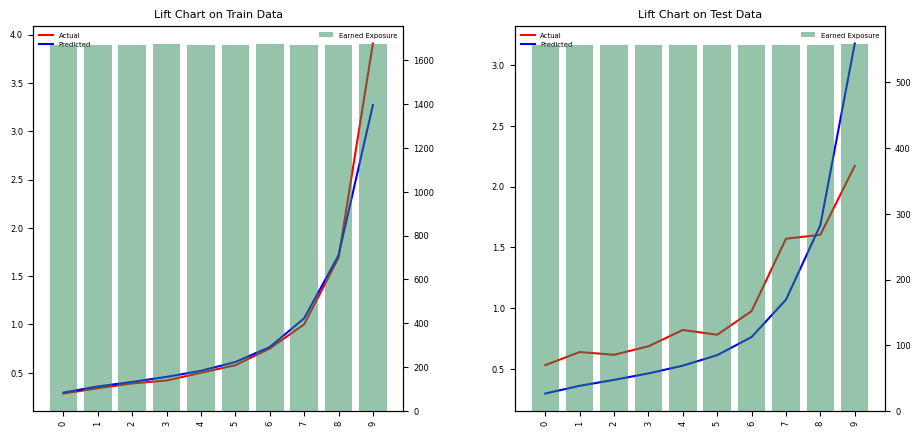

In [ ]:
for model in model_names:
    model_dict[model].plot_lift(model_label='ResNet', pred_nme='pred_resn')

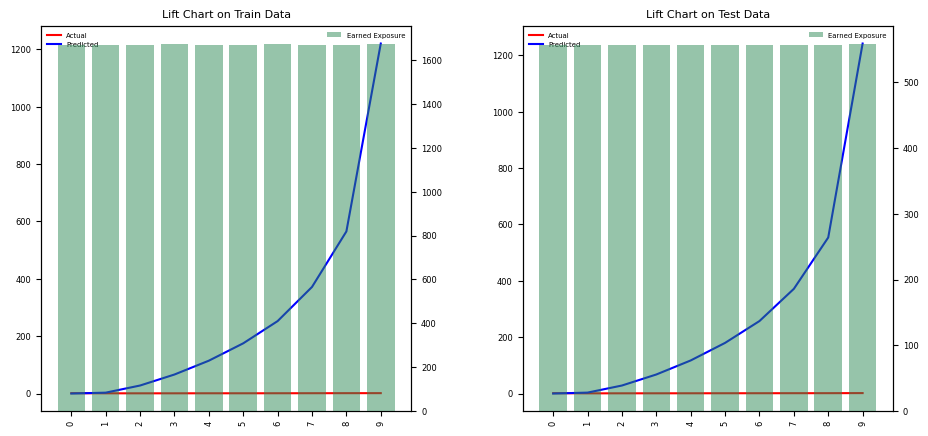

In [ ]:
for model in model_names:
    model_dict[model].plot_lift(
        model_label='FT Transformer', pred_nme='pred_ft')